# 02 Saliency Exploration

Implements and tests all four saliency methods (vanilla gradients, guided backpropagation, GradCAM, integrated gradients) on a single fixed development image.

#### Setup

In [17]:
# Import libraries, project config, and the saliency functions being developed in src/saliency.py
import captum; print(captum.__version__)
import torchxrayvision as xrv
import skimage, torch, torchvision
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.saliency import compute_vanilla_gradients, compute_guided_backprop, compute_gradcam, compute_integrated_gradients
from src.saliency import compute_dataset_mean_baseline, overlay_saliency

0.9.0


Model + fixed dev image loading:

In [ ]:
# Reload the pretrained torchxrayvision DenseNet model, trained on the CheXpert dataset
model = xrv.models.DenseNet(weights="densenet121-res224-chex")

In [ ]:
# Preprocess the fixed development image (`00015770_011.png`, true label Cardiomegaly, prediction confidence 0.959) used to build and test each method.
img = skimage.io.imread("../data/xray_dataset/00015770_011.png")
img = xrv.datasets.normalize(img, 255)              # Convert 8-bit image to [-1024, 1024] range
img = img[None, ...]                                # Equivalent to (1, height, weight) - image is 2 dimensions so need to add in channels

transform = torchvision.transforms.Compose([xrv.datasets.XRayCenterCrop(),xrv.datasets.XRayResizer(224)])
img = transform(img)
img = torch.from_numpy(img)
img = img.unsqueeze(0)                              # Adds batch dimension to the front: (batch, channels, height, width)

#### Testing gradient functions

**Vanilla gradients.** Computes the raw gradient of the model's output with respect to each input pixel; a direct measure of local sensitivity, but known to be noisy and potentially unstable under small input perturbations

(224, 224) 0.0 1.0


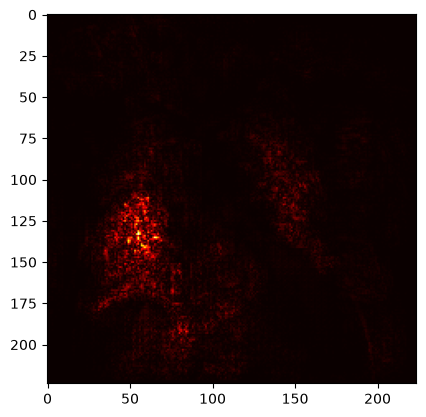

In [5]:
target_class = model.pathologies.index('Cardiomegaly')
result = compute_vanilla_gradients(model, img, target_class)
print(result.shape, result.min(), result.max())
plt.imshow(result, cmap='hot')

**Guided backpropagation.** Similar to vanilla gradients, but only propagates positive gradient contributions backward through ReLU layers, typically producing visually sharper maps. Though prior studies  (Adebayo et al., 2018) have found this sharpness doesn't always reflect learned model weights.

(224, 224) 0.0 1.0


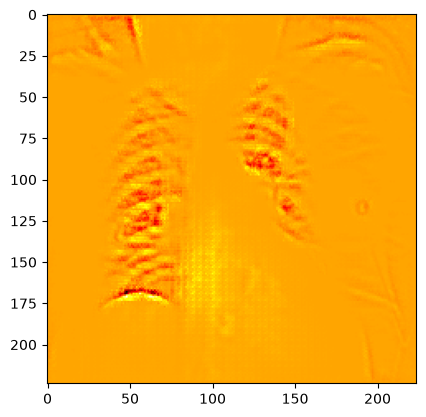

In [6]:
target_class = model.pathologies.index('Cardiomegaly')
result = compute_guided_backprop(model, img, target_class)
print(result.shape, result.min(), result.max())
plt.imshow(result, cmap='hot')

**GradCAM.** Uses gradients flowing into the final convolutional block (`denseblock4`) rather than the input pixels directly, producing a coarse (7×7) attribution map upsampled to full resolution. Spatially cruder than pixel-level methods, but tied more directly to high-level learned features.

torch.Size([1, 1, 7, 7]) tensor(-0.0003, grad_fn=<MinBackward1>) tensor(0.0041, grad_fn=<MaxBackward1>)
(224, 224) 0.0 1.0


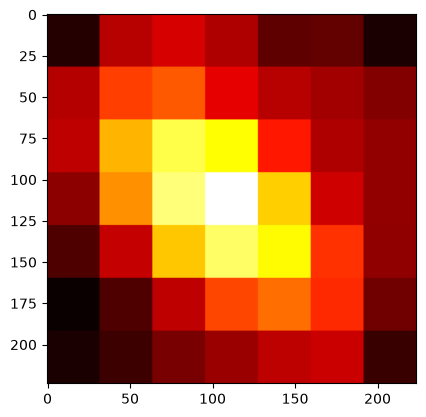

In [ ]:
target_class = model.pathologies.index('Cardiomegaly')
result = compute_gradcam(model, img, target_class, target_layer=model.features.denseblock4) # Uses gradients flowing into final convolutional block here
print(result.shape, result.min(), result.max())
plt.imshow(result, cmap='hot')

**Baseline dataset-mean image.** Computes the dataset-mean image (across all 250 sampled X-rays) to serve as the "absence of signal" baseline for Integrated Gradients, chosen over an all-black baseline since it stays closer to realistic X-ray input space.

torch.Size([1, 1, 224, 224]) -903.4296264648438 692.5464477539062


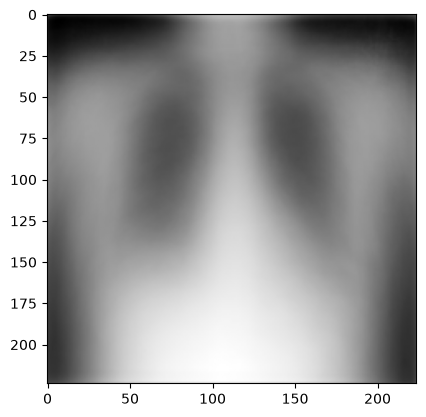

In [8]:
sampled_data_labels = pd.read_csv('../data/sampled_data_labels.csv')
baseline = compute_dataset_mean_baseline(sampled_data_labels['Image Index'].tolist(), '../data/xray_dataset')
print(baseline.shape, baseline.min().item(), baseline.max().item())
plt.imshow(baseline.squeeze().detach().numpy(), cmap='gray')

**Integrated gradients.** Averages gradients along an interpolation path from the dataset-mean baseline to the actual image, producing a more stable attribution than a single gradient snapshot. Uses `n_steps=20` and `internal_batch_size=5` due to CPU memory constraints encountered during testing.

(224, 224) 0.0 1.0


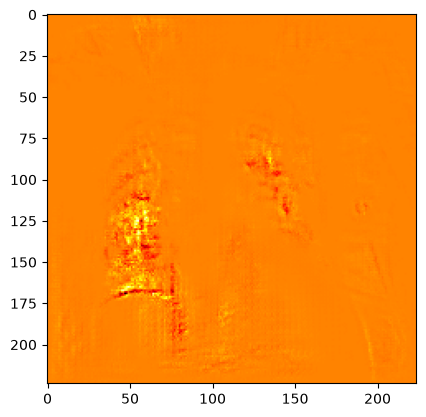

In [9]:
target_class = model.pathologies.index('Cardiomegaly')
result = compute_integrated_gradients(model, img, target_class, baseline, n_steps=20, internal_batch_size=5)
print(result.shape, result.min(), result.max())
plt.imshow(result, cmap='hot')

Testing `overlay_saliency`, which blends a saliency map over the original X-ray as a semi-transparent heatmap for visual inspection.

torch.Size([224, 224])


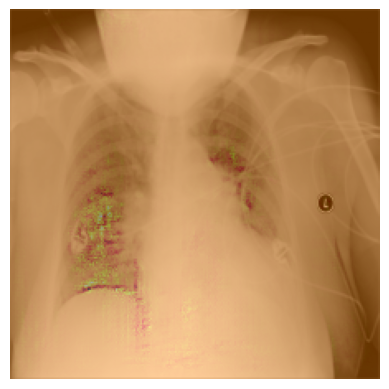

In [ ]:
img = img.squeeze().detach().numpy()
print(img.shape)
fig, ax = overlay_saliency(img, result, alpha=0.4)
plt.show()